<a href="https://colab.research.google.com/github/AnannyaMathewKJ/Anannya_Mathew/blob/main/Week2_Anannya_Mathew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

In [ ]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
np.random.seed(42)
date_range = pd.date_range(start="2024-01-01", end="2026-05-01", freq="D")
n_days = len(date_range)

In [ ]:
price = np.random.uniform(low=15.0, high=25.0, size=n_days)
is_promo = np.random.choice([0, 1], size=n_days, p=[0.85, 0.15])

In [ ]:
base_sales = 200
seasonality = 50 * np.sin(2 * np.pi * date_range.dayofyear / 365.25)
price_effect = -5 * price
promo_effect = 80 * is_promo
noise = np.random.normal(0, 15, size=n_days)

sales = base_sales + seasonality + price_effect + promo_effect + noise
sales = np.clip(sales, 10, None)

#Loading Dataset from kegglehub to colab

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

print("Path to dataset files:", path)

100%|██████████| 64.8k/64.8k [00:00<00:00, 42.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/versions/1


#Checking Files containig inside that path

In [ ]:
import os
os.listdir('/root/.cache/kagglehub/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/versions/1')

['tesla_deliveries_dataset_2015_2025.csv']

In [ ]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/versions/1/tesla_deliveries_dataset_2015_2025.csv')
df.head(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [ ]:
df.dtypes

,0
Year,int64
Month,int64
Region,object
Model,object
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64


In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [ ]:
df.drop_duplicates()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


#Exploratory Data Analysis
1. Distribution of Average Price

Text(0, 0.5, 'Frequency')

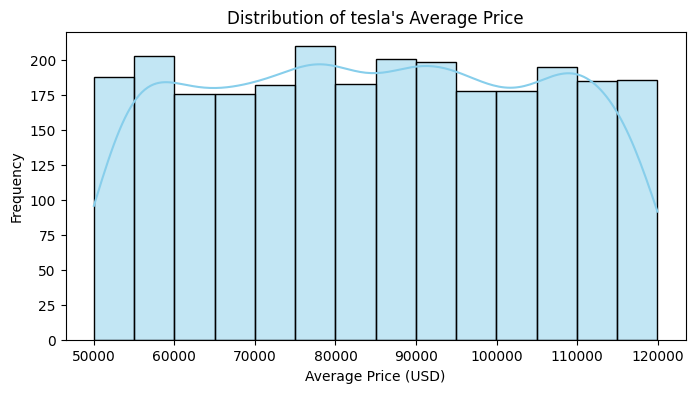

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Avg_Price_USD'], kde=True, color = 'skyblue' )
plt.title("Distribution of tesla's Average Price")
plt.xlabel("Average Price (USD)")
plt.ylabel("Frequency")

2. Production Units Over Time by Vehicle Model

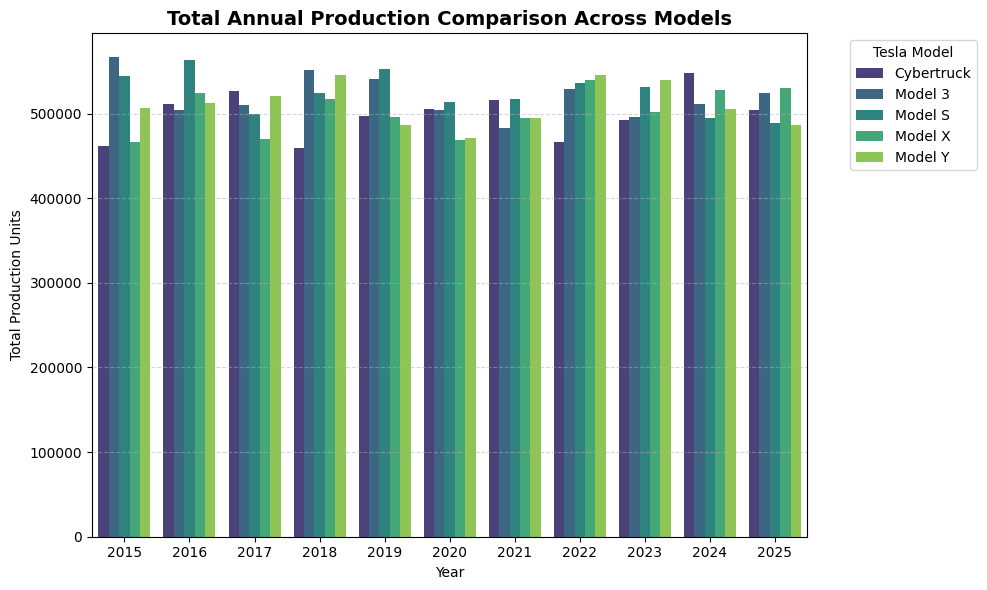

In [ ]:
# Aggregate total production per year per model
annual_df = df.groupby(['Year', 'Model'])['Production_Units'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=annual_df, x='Year', y='Production_Units', hue='Model', palette='viridis')

plt.title('Total Annual Production Comparison Across Models', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Production Units')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Tesla Model', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

3. Correlation Matrix Heatmap

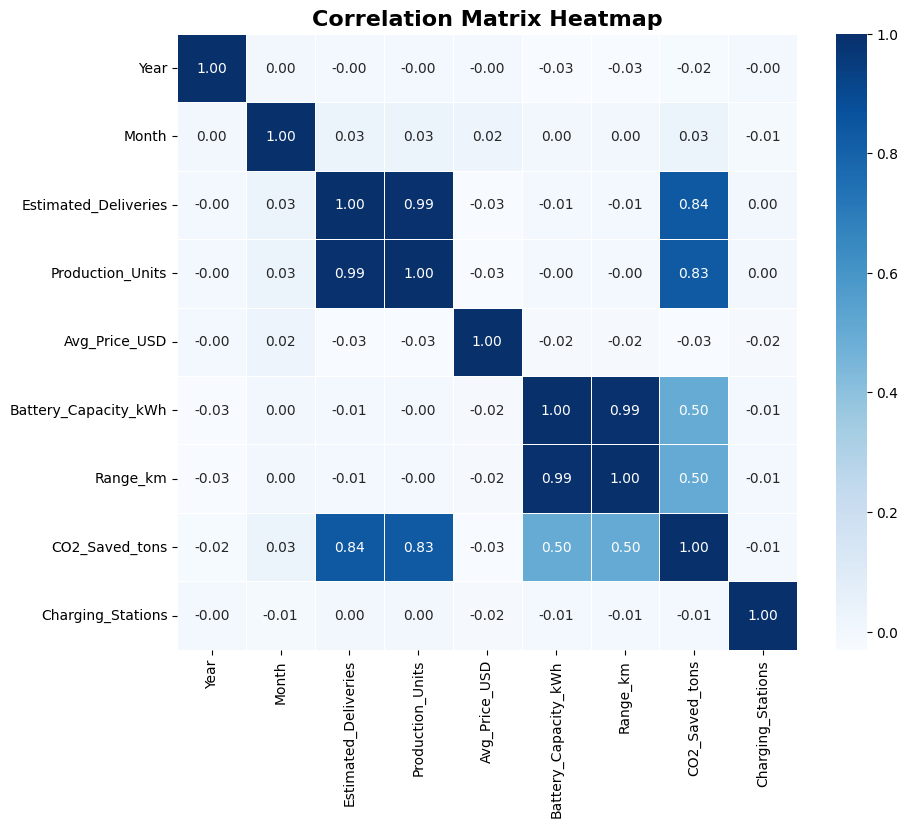

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold')
plt.show()

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df_ts = df.groupby('Date').agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units': 'sum',
    'Avg_Price_USD': 'mean',
    'Battery_Capacity_kWh': 'mean',
    'Range_km': 'mean'
}).sort_index()
print("Pipeline Data Framework Ready. Shape:", df_ts.shape)
print(df_ts.head())

Pipeline Data Framework Ready. Shape: (132, 5)
            Estimated_Deliveries  Production_Units  Avg_Price_USD  \
Date                                                                
2015-01-01                183180            195793     84502.4970   
2015-02-01                165053            176119     81745.5695   
2015-03-01                184567            200151     86221.2895   
2015-04-01                225623            241706     83446.1640   
2015-05-01                184264            198205     85632.1110   

            Battery_Capacity_kWh  Range_km  
Date                                        
2015-01-01                 85.45    491.35  
2015-02-01                 85.25    494.55  
2015-03-01                 84.75    490.35  
2015-04-01                 92.35    527.95  
2015-05-01                 95.85    552.70  


In [ ]:
# Create a fresh copy of your loaded dataframe
df_features = df.copy()

# 1. Clean column names and fix the Date Index
df_features.columns = df_features.columns.str.strip()
if 'Date' in df_features.columns:
    df_features['Date'] = pd.to_datetime(df_features['Date'])
    df_features.set_index('Date', inplace=True)
else:
    # If Date isn't a column, construct it from Year and Month
    df_features['Date'] = pd.to_datetime(df_features['Year'].astype(str) + '-' + df_features['Month'].astype(str) + '-01')
    df_features.set_index('Date', inplace=True)

df_features.sort_index(inplace=True)

# 2. Convert text columns (like 'North America') into numbers using One-Hot Encoding
categorical_cols = df_features.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    print(f"Encoding text columns to numbers: {categorical_cols}")
    df_features = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True, dtype=float)

# 3. Extract Temporal Features
df_features['Month_Factor'] = df_features.index.month

# 4. Generate Lag & Rolling Features safely on numeric data
df_features['Deliveries_Lag_1'] = df_features['Estimated_Deliveries'].shift(1)
df_features['Deliveries_Lag_2'] = df_features['Estimated_Deliveries'].shift(2)
df_features['Deliveries_Roll_Mean_3'] = df_features['Estimated_Deliveries'].shift(1).rolling(window=3).mean()
df_features['Deliveries_Roll_Std_3'] = df_features['Estimated_Deliveries'].shift(1).rolling(window=3).std()

# Drop rows with NaN values caused by shifting
df_features.dropna(inplace=True)

print("\nData successfully transformed! All columns are now numeric.")
print(f"New Data Shape: {df_features.shape}")

Encoding text columns to numbers: ['Region', 'Model', 'Source_Type']

Data successfully transformed! All columns are now numeric.
New Data Shape: (2637, 23)


In [ ]:
# Target variable is Estimated_Deliveries
X = df_features.drop(columns=['Estimated_Deliveries'])
y = df_features['Estimated_Deliveries']

# Set aside the last 12 months as the validation/test horizon
test_horizon = 12
X_train, X_test = X.iloc[:-test_horizon], X.iloc[-test_horizon:]
y_train, y_test = y.iloc[:-test_horizon], y.iloc[-test_horizon:]

print(f"Training Window: {X_train.index.min().strftime('%Y-%m')} to {X_train.index.max().strftime('%Y-%m')} ({len(X_train)} months)")
print(f"Testing Horizon: {X_test.index.min().strftime('%Y-%m')} to {X_test.index.max().strftime('%Y-%m')} ({len(X_test)} months)")

Training Window: 2015-01 to 2025-12 (2625 months)
Testing Horizon: 2025-12 to 2025-12 (12 months)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

# Initialize base model
rf_model = RandomForestRegressor(random_state=42)

# Define hyperparameter distribution grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Cross-validation setup for time-series data
tscv = TimeSeriesSplit(n_splits=3)

# Search setup
rf_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
                               n_iter=10, cv=tscv, scoring='neg_mean_squared_error',
                               random_state=42, n_jobs=-1)

print("Optimizing Regressor Parameters...")
rf_search.fit(X_train, y_train)

# Extract best model and predict
best_rf = rf_search.best_estimator_
y_pred_ml = best_rf.predict(X_test)

print(f"Optimal Parameters Identified: {rf_search.best_params_}")

Optimizing Regressor Parameters...
Optimal Parameters Identified: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


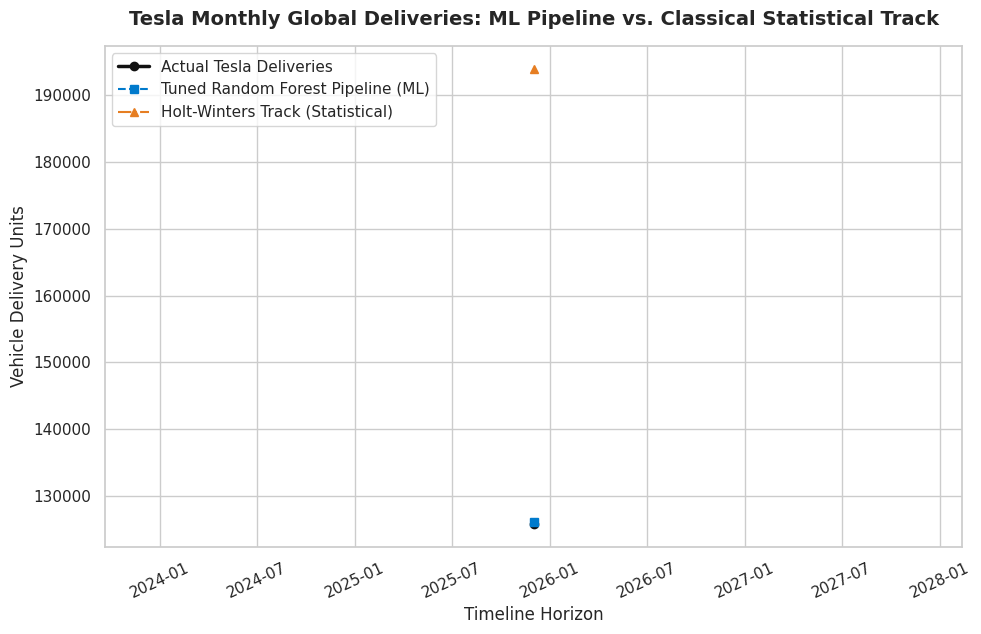

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fit Classical Time Series Model (Holt-Winters)
# We aggregate training data by date to ensure a continuous index for the statistical model
y_train_grouped = y_train.groupby(level=0).sum()
y_test_grouped = y_test.groupby(level=0).sum()

ts_baseline = ExponentialSmoothing(y_train_grouped, seasonal_periods=12, trend='add', seasonal='add')
ts_fitted = ts_baseline.fit()
y_pred_stat = ts_fitted.forecast(steps=len(y_test_grouped))

# Align ML predictions by date for a fair graphical comparison
ml_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_ml}, index=y_test.index)
ml_grouped = ml_results.groupby(level=0).sum()

# 2. Performance Comparison Charts
plt.figure(figsize=(10, 6.5))
plt.plot(y_test_grouped.index, y_test_grouped.values, label='Actual Tesla Deliveries', color='#111111', linewidth=2.5, marker='o')
plt.plot(ml_grouped.index, ml_grouped['Predicted'], label='Tuned Random Forest Pipeline (ML)', color='#007acc', linestyle='--', marker='s')
plt.plot(y_test_grouped.index, y_pred_stat.values, label='Holt-Winters Track (Statistical)', color='#e67e22', linestyle='-.', marker='^')

plt.title('Tesla Monthly Global Deliveries: ML Pipeline vs. Classical Statistical Track', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline Horizon', fontsize=12)
plt.ylabel('Vehicle Delivery Units', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()